# SFINCS Demo

In this demo, we will practice building and creating a SFINCS model for the NJ coast from Sandy Hook to Asbury Park during Hurricane Sandy. The northern half (Sandy Hook spit + Sandy Hook Bay) is included so the offshore boundary can carry the alongshore gradient observed during Sandy, and so the NOAA Sandy Hook gauge falls inside the domain for validation.

## Data Sources

| Dataset | Source | File | Purpose |
|---------|--------|------|---------|
| **2010 USACE NCMP topobathy** | NOAA / USACE (pre-Sandy, NOAA ID 9456) | `data/elevation/usace_nj_2010_topobathy.tif` | 1 m **pre-Hurricane-Sandy** topobathy on the dune / beach / nearshore strip. Captures the dune state that existed on 2012-10-29 — before ~$1B of post-storm beach replenishment. NAVD88. |
| NOAA CUDEM 1/9" topobathy | NOAA NCEI northeast_sandy (2014–2018) | `data/elevation/cudem_asbury.tif` | ~3 m topobathy fill for inlets + shelf seaward of the dune line, where the 2010 NCMP product has NoData. NAVD88. |
| NJ 10-ft LiDAR DEM | NJ OGIS statewide mosaic (2014–2019) | `data/elevation/nj_10ft_dem.tif` | Inland topography where CUDEM has no data. |
| GEBCO 2026 | GEBCO global grid | `data/elevation/gebco_nj.tif` | ~450 m offshore tail (anything seaward of CUDEM). |
| **NOAA CO-OPS water levels** | NOAA Tides & Currents API (gauges 8518750, 8531680, 8534720, 8536110) | `data/gtsm/noaa_sandy_nj.nc` | Observed hourly water levels (m NAVD88) at four NJ/NY gauges spanning the boundary. Replaces an earlier GTSM-ERA5 hindcast that under-predicted Sandy's peak by ~1 m on the NJ shelf. Sandy Hook (8531680) failed mid-storm; The Battery (~5 km north) carries the peak. |
| ERA5 winds + pressure | Copernicus CDS (`reanalysis-era5-single-levels`) | `data/era5/era5_nj_sandy_2012_10_28_31.nc` | 10-m wind components and MSLP forcing (hourly, Oct 28–31 2012). |
| NLCD 2012 land cover | USGS/MRLC | `data/roughness/nlcd_2012.tif` | Manning's roughness reclass via `NLCD_SFBD_mapping.csv`. |

### Elevation merge logic (four-tier, top → bottom)

`setup_dep` and `setup_subgrid` fill the DEM in dataset order — later entries only fill NoData left by earlier ones:

1. **2010 USACE NCMP** (no filter) — pre-Sandy 1 m topobathy on the coastal strip. Takes priority where it has data: the surge-relevant surface (dunes, beach, surf zone) is the 2010 state, not the modern engineered state.
2. **CUDEM** — fills inlet channels + nearshore + shallow shelf where the NCMP strip ends.
3. **NJ 10-ft LiDAR** (`zmin=0.001`) — fills inland land. The `zmin` filter excludes LiDAR's hydroflattened water surfaces so they don't overwrite real channel depths underneath.
4. **GEBCO** — offshore tail for the deeper shelf.

> **Why pre-Sandy data?** This is a *hindcast* of Sandy. Modern topobathy products (e.g. the 2022 USACE DEM, post-2013 USGS CoNED) include beach replenishment and engineered dunes that didn't exist on 2012-10-29 — using them systematically under-predicts overtopping. The 2010 NCMP product is the closest pre-storm 1 m topobathy available for the NJ coast.

In [1]:
# Imports
import os
import subprocess
from datetime import datetime
from pathlib import Path

import geopandas as gpd
import hvplot.pandas
import hvplot.xarray
import matplotlib.pyplot as plt
import pandas as pd
import rioxarray
import xarray as xr
from hydromt._utils import log
from hydromt_sfincs import DATADIR, SfincsModel, utils
from shapely.geometry import Point



## Phase 1 — Static build

Everything here depends only on **geometry, topography, and roughness** — grid, elevation, mask, observation points, and the subgrid tables. It's the expensive part (the subgrid build spikes to ~13 GB RAM), but it's a **one-time cost**: the outputs are written to disk and SFINCS just reads them.

**Re-run Phase 1 only when one of these changes:** region/resolution, the elevation datasets or merge order, the roughness datasets or reclass table, `nr_subgrid_pixels`, or the mask `zmin`/boundary logic.

If you're only changing **forcing** (water level, wind, pressure, timing), skip straight to Phase 2 — it reopens this model from disk and never touches the subgrid build.

### 1. Initialize SfincsModel, set data library, and output folder

In [2]:
model_root = "../model"

log.initialize_logging()
log.set_log_level(log_level=30)  # Only errors and critical

# Add file handler to log to a file
log_file = Path(model_root) / "hydromt_sfincs.log"
logger = log._add_filehandler(log_file)

# Add data catalogs
data_libs = ["/home/zagreus/nj_sandy_sfincs/data/data_catalog.yml"]

# Create model
sf = SfincsModel(
    data_libs=data_libs, root=model_root, mode="w+", write_gis=True
)


2026-05-14 14:59:31,497 - hydromt.model.model - model - WARNING - No region component found in components.


### 2. Specify grid

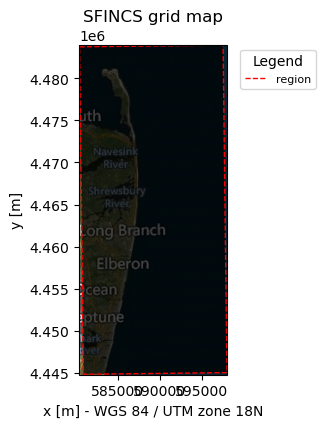

In [3]:
# Create grid from region.  50 m (was 100 m) so the 1 m topobathy data
# is sampled into a grid that can actually resolve the barrier-island
# dune line; subgrid pixels below give a ~3 m effective resolution.
sf.grid.create_from_region(
    region={"geom": "/home/zagreus/nj_sandy_sfincs/data/region.geojson"},
    res=50,
    rotated=True,
    crs="utm",
)

# Show model grid outline
_ = sf.plot_basemap(
    variable="grid",
    plot_region=True,
    bmap="sat",
    zoomlevel=10,
    grid_kwargs={"linewidth": 0.3},
)


### 3. Add elevation

2026-05-14 14:59:53,156 - hydromt.hydromt_sfincs.components.grid.elevation - elevation - WARNING - Interpolate elevation at 1 cells


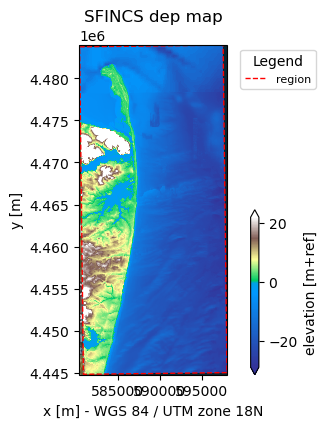

In [4]:
elevation_list = [
    {"elevation": "usace_nj_2010"},                # 1 m pre-Sandy topobathy: dunes, beach, surf zone
    {"elevation": "cudem_nj"},                     # 3 m fill: inlet channels + shelf
    {"elevation": "nj_10ft_dem", "zmin": 0.001},   # 3 m fill: inland (drop hydroflat water)
    {"elevation": "gebco_nj"},                     # 450 m offshore tail
]

sf.elevation.create(elevation_list=elevation_list, buffer_cells=1)

# Plot the merged topobathy (colour limits set between -25 m and +10 m to show NJ shelf)
_ = sf.plot_basemap(
    variable="dep",
    plot_region=True,
    bmap="sat",
    zoomlevel=10,
)

### 4. Make mask of activate and inactive cells

2026-05-14 15:00:26,074 - hydromt.model.components.grid - grid - WARNING - Replacing grid map: mask


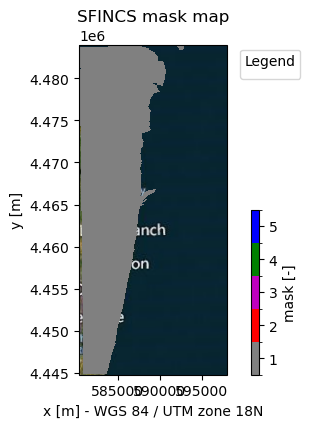

In [6]:
# All cells with elevation >= -10 m are considered active
# The NJ shelf is shallow, so -10 m captures it without going too far offshore
sf.mask.create_active(zmin=-10)

_ = sf.plot_basemap(
    variable="mask",
    plot_region=False,
    plot_bounds=True,
    bmap="sat",
    zoomlevel=10,
)

### 5. Update mask with boundary cells

Two boundary types are set on the perimeter of the active mask:
- **Water level (mask=2)** on the deep-ocean edge (`zmax=-1`) — where NOAA CO-OPS forcing is applied.
- **Outflow (mask=3)** on the lateral/inland edges at low elevation (`-1 ≤ zb ≤ 2 m`) — lets surge that propagates into back-bay channels (Shark River, Sandy Hook Bay) drain out of the domain instead of piling up against the model edge.

2026-05-14 15:00:39,288 - hydromt.model.components.grid - grid - WARNING - Replacing grid map: mask


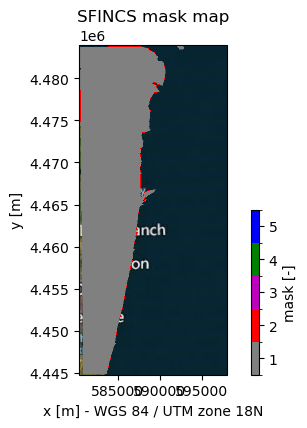

In [7]:
# Mark offshore edge cells (depth > 1 m) as water level boundary cells
sf.mask.create_boundary(
    btype="waterlevel",
    zmax=-1,
    reset_bounds=True,
)

_ = sf.plot_basemap(
    variable="mask",
    plot_region=False,
    plot_bounds=False,
    bmap="sat",
    zoomlevel=10,
)

2026-05-14 15:00:51,012 - hydromt.model.components.grid - grid - WARNING - Replacing grid map: mask


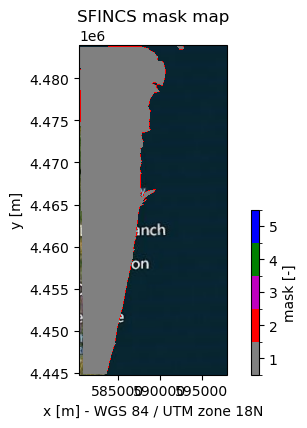

In [8]:
# Add outflow cells (mask=3) on the lateral/inland edges of the active mask.
# zmin/zmax restricts to channels/back-bay cells; high dune cells stay as
# regular interior land (no outflow needed). reset_bounds=False preserves
# the offshore water-level boundary set above.
sf.mask.create_boundary(btype="outflow", zmin=-1, zmax=2, reset_bounds=False)

_ = sf.plot_basemap(
    variable="mask",
    plot_region=False,
    plot_bounds=False,
    bmap="sat",
    zoomlevel=10,
)

### 6. Add observation points

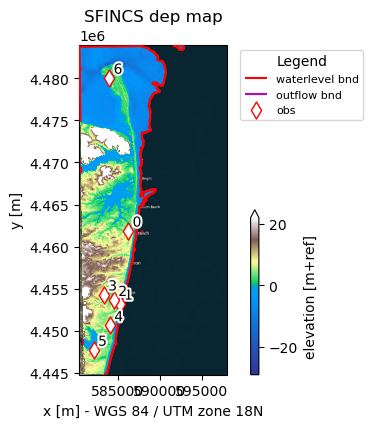

In [9]:
# Project obs points + a Sandy Hook NOAA gauge location for validation.
# The Sandy Hook 8531680 gauge falls inside the expanded domain — comparing
# modeled zs(t) here against the observed record (where it survived, up to
# ~21:00 UTC on 2012-10-29) is the cleanest single-point check on the model.
obs_gdf = gpd.read_file("../data/obs.geojson")
extras = gpd.GeoDataFrame(
    {"name": ["sandy_hook_gauge", "offshore_test"]},
    geometry=[
        Point(-74.0091, 40.4669),  # NOAA 8531680
        Point(-73.92,   40.20),    # offshore validation
    ],
    crs="EPSG:4326",
)
obs_all = gpd.GeoDataFrame(
    pd.concat([obs_gdf, extras], ignore_index=True),
    crs="EPSG:4326",
)
sf.observation_points.create(locations=obs_all, merge=False)

_ = sf.plot_basemap(
    variable="dep",
    plot_geoms=True,
    plot_bounds=True,
    bmap="sat",
    zoomlevel=12,
)

### 7. Make subgrid derived tables

Subgrid tables bake elevation and roughness into per-cell lookup tables at higher effective resolution. SFINCS uses these directly and **ignores any standalone manningfile** when subgrid is active, so we set roughness here rather than as a separate model layer.

In [10]:
# NLCD → Manning reclass table (hydromt_sfincs built-in; SFBD-tuned — TODO: swap for CONUS table)
reclass_table = os.path.join(DATADIR, "lulc", "NLCD_SFBD_mapping.csv")

elevation_list = [
    {"elevation": "usace_nj_2010"},                # 1 m pre-Sandy topobathy: dunes, beach, surf zone
    {"elevation": "cudem_nj"},                     # 3 m fill: inlet channels + shelf
    {"elevation": "nj_10ft_dem", "zmin": 0.001},   # 3 m fill: inland (drop hydroflat water)
    {"elevation": "gebco_nj"},                     # 450 m offshore tail
]
roughness_list = [{"lulc": "nlcd_2012", "reclass_table": reclass_table}]

# nr_subgrid_pixels=8 (was 16) so the 50 m grid samples ~3 m effective —
# fine enough to capture the dune line from the 1 m USACE topobathy.
sf.subgrid.create(
    elevation_list=elevation_list,
    roughness_list=roughness_list,
    nr_subgrid_pixels=8,
    write_dep_tif=True,
    write_man_tif=True,
)

2026-05-14 15:01:23,284 - hydromt.gis.raster - raster - WARNING - The nodata value None is not in the reclass table.None will be used for the params.
2026-05-14 15:01:30,233 - hydromt.hydromt_sfincs.components.grid.subgrid - subgrid - WARNING - Fill manning roughness data at 1127 subgrid pixels with default values
2026-05-14 15:01:41,657 - hydromt.hydromt_sfincs.components.grid.subgrid - subgrid - WARNING - Fill manning roughness data at 391 subgrid pixels with default values
2026-05-14 15:01:51,846 - hydromt.hydromt_sfincs.components.grid.subgrid - subgrid - WARNING - Fill manning roughness data at 6194 subgrid pixels with default values


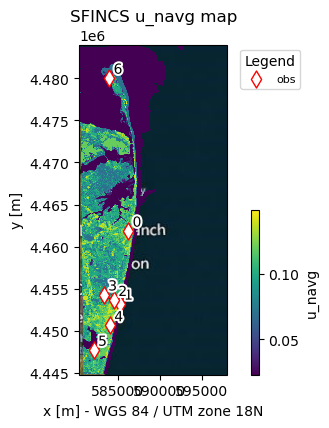

In [11]:
# Plot one of the 2D subgrid variables — u_navg is the representative depth for momentum fluxes
_ = sf.plot_basemap(
    variable=sf.subgrid.data["u_navg"],
    plot_bounds=False,
    bmap="sat",
    zoomlevel=10,
)

In [12]:
# --- End of Phase 1: write the static model to disk ---
# Grid, elevation, mask, subgrid tables, and obs points are now on disk.
# None of this depends on forcing, so you don't need to rebuild it when
# iterating on water level / wind / pressure — Phase 2 reopens from here.
sf.write()

# Free the build-time memory. The data-catalog cache + source DEMs held
# ~10 GB resident after the build; Phase 2 opens a fresh handle and doesn't
# need any of it. (Restarting the kernel here works just as well.)
del sf
import gc; gc.collect()

7850

## Phase 2 — Forcing & run

Everything from here depends on **forcing**, not geometry: water level, wind, pressure, and the simulation time window. This is the cheap, fast-iterating half — no DEM loads, no subgrid build, ~30 s instead of ~10 min.

**Entry point:** the cell below reopens the static model from Phase 1 in `r+` mode. If you just ran Phase 1 in this same kernel it was `del`'d to free memory, so run this cell either way. Safe after a kernel restart — it only needs the imports cell near the top.

In [13]:
# --- Phase 2 entry point: reopen the static model from disk ---
# mode="r+" opens the existing Phase 1 model and allows updating it in place.
# Re-defined here (not just in the Phase 1 init cell) so this works as a
# standalone entry point after a kernel restart.
model_root = "../model"
data_libs = ["/home/zagreus/nj_sandy_sfincs/data/data_catalog.yml"]

sf = SfincsModel(model_root, data_libs=data_libs, mode="r+")

2026-05-14 15:05:18,298 - hydromt.model.model - model - WARNING - No region component found in components.


### 1. Add water level time-series as forcing

Observed NOAA CO-OPS hourly water levels at four NJ/NY gauges (Battery, Sandy Hook, Atlantic City, Cape May) over Oct 28–31 2012, in NAVD88. Replaces an earlier GTSM-ERA5 hindcast that under-predicted Sandy's peak by ~1 m at NJ-coast latitudes (2.91 m vs ~3.86 m observed at Sandy Hook). The Sandy Hook gauge failed mid-storm — The Battery (~5 km north, online) carries the cleanest peak-amplitude signal for that latitude.

In [14]:
# Set the simulation period to cover Hurricane Sandy's landfall
sf.config.update(
    {
        "tref": datetime(2012, 10, 28),
        "tstart": datetime(2012, 10, 29),
        "tstop": datetime(2012, 10, 31),
        "dtmapout": 3600.0,   # hourly map snapshots -> creates sfincs_map.nc
        "dtmaxout": 86400.0,  # write max values once per day
        "dthisout": 600.0,    # observation point output every 10 min
    }
)

# Apply observed NOAA CO-OPS water levels (Battery, Sandy Hook, Atlantic City,
# Cape May) to boundary cells. Replaces the prior GTSM-ERA5 forcing, which
# under-predicted the Sandy peak by ~1 m on the NJ shelf — ERA5 winds are
# sampled too far offshore to drive the near-shore setup, and global tide-surge
# models miss the NY Bight resonance. Observed gauges carry both signals.
# buffer=50000 m → each boundary cell uses the nearest NOAA station within 50 km.
sf.water_level.create(
    geodataset="noaa_sandy_nj",
    buffer=50000,
)

### 2. Add ERA5 wind + pressure forcing

ERA5 hourly 10-m winds (`wind10_u`, `wind10_v`) and mean sea-level pressure (`press_msl`) over [42°N, -76°W, 37°S, -72°E] for Oct 28-31, 2012. Wind setup on the NJ shelf was the dominant surge driver during Sandy. Note: with NOAA-gauge boundary forcing the inverse-barometer signal is already embedded in the boundary water levels — MSLP forcing inside the domain now mainly drives the *internal* pressure gradient, not the surge magnitude at the boundary itself.

In [15]:
# ERA5 file is pre-renamed to hydromt_sfincs conventions
# (wind10_u, wind10_v in m/s; press_msl in Pa; coords time/y/x).
# Both methods clip to the model bbox + time range internally.
sf.wind.create(wind="era5_nj")
sf.pressure.create(press="era5_nj")

### 3. Save out model

Writes the forcing (and updated config) into the model directory alongside the Phase 1 static files.

In [16]:
# write all model files to disk
sf.write()

## Running the model

### 1. Run via Docker

In [ ]:
log_path = Path(model_root) / "sfincs_log.txt"
model_abs = Path(model_root).resolve()

# Remove stale output files before running — Docker writes them as root, and SFINCS
# gets "NetCDF: Not a valid ID" errors if it tries to overwrite root-owned files.
subprocess.run(
    [
        "docker", "run", "--rm",
        "-v", f"{model_abs}:/data",
        "--entrypoint", "/bin/sh",
        "deltares/sfincs-cpu:latest",
        "-c", "rm -f /data/sfincs_map.nc /data/sfincs_his.nc",
    ],
    capture_output=True,
)

print(f"Running SFINCS via Docker on {model_abs} ...")
with open(log_path, "w") as log_file:
    result = subprocess.run(
        [
            "docker", "run", "--rm",
            "-v", f"{model_abs}:/data",
            "deltares/sfincs-cpu:latest",
        ],
        stdout=log_file,
        stderr=subprocess.STDOUT,
    )
print(f"Done (return code {result.returncode})")


Running SFINCS via Docker on /home/zagreus/nj_sandy_sfincs/model ...


In [ ]:
# Read the SFINCS log file
log_path = Path(model_root) / "sfincs_log.txt"
if log_path.exists():
    print(log_path.read_text())
else:
    print("No log file found — SFINCS has not run yet.")

In [ ]:
# Check that output files were created
map_nc = Path(model_root) / "sfincs_map.nc"
his_nc = Path(model_root) / "sfincs_his.nc"

print(f"sfincs_map.nc exists: {map_nc.exists()}")
print(f"sfincs_his.nc exists: {his_nc.exists()}")

## Visualization

### 1. Read Model Results

In [ ]:
# Open the model read-only for result inspection. Defined standalone so the
# Visualization section works after a kernel restart (doesn't depend on the
# Phase 1 / Phase 2 build cells still being in scope).
model_root = "../model"
data_libs = ["/home/zagreus/nj_sandy_sfincs/data/data_catalog.yml"]
model_abs = Path(model_root).resolve()

mod = SfincsModel(model_root, data_libs=data_libs, mode="r")
mod.output.read()

print("Output variables available:")
list(mod.output.data.keys())

In [ ]:
# Plot the model layout — grid, boundary cells, and observation points
fig, ax = mod.plot_basemap(fn_out=None, bmap="sat", figsize=(9, 7), geom_names=["obs"])

### Diagnostic: peak modeled water level vs. dune crest vs. observed surge

Before adding wave physics, figure out *which* water level is missing:
- If modeled peak `zs` ≪ observed NOAA peak → the **surge boundary** is the problem, not waves.
- If modeled peak `zs` ≈ observed NOAA peak but `zb` (local crest) is higher → wave setup/runup is the gap.
- If modeled `zs` overtops `zb` at some obs points but no inland flooding shows up → connectivity / subgrid smoothing.

The `NOAA_PEAKS_NAVD88` dict below is **approximate** — edit with verified values from tidesandcurrents.noaa.gov for the closest gauge to each obs point.

In [ ]:
# Sandy peak still-water levels at NOAA gauges (m NAVD88), used to validate
# obs points that sit ON or NEAR a known gauge. `sandy_hook_gauge` is the
# direct validation point — its 3.86 m value is the canonical peak storm tide
# (gauge failed mid-storm; The Battery, ~5 km north, recorded 3.42 m and is
# generally cited as a lower bound for Sandy Hook's peak).
NOAA_PEAKS_NAVD88 = {
    "sandy_hook_gauge": 3.86,   # 8531680 (canonical Sandy peak storm tide)
}

point_zs = mod.output.data["point_zs"]   # (time, station)
point_zb = mod.output.data["point_zb"]   # (station,)
names = [n.decode() if isinstance(n, bytes) else str(n)
         for n in point_zs["station_name"].values]

rows = []
for i, name in enumerate(names):
    zs_ts = point_zs.isel(stations=i)
    zb = float(point_zb.isel(stations=i).values)
    zs_peak = float(zs_ts.max().values)
    t_peak = pd.Timestamp(zs_ts["time"].values[int(zs_ts.argmax().values)])
    freeboard = zb - zs_peak  # +ve = dune stayed dry, -ve = overtopped
    rows.append({
        "obs_point": name,
        "zb [m]": round(zb, 2),
        "modeled zs_peak [m]": round(zs_peak, 2),
        "t_peak [UTC]": t_peak.strftime("%m-%d %H:%M"),
        "freeboard zb-zs [m]": round(freeboard, 2),
        "NOAA peak [m]": NOAA_PEAKS_NAVD88.get(name, None),
        "model - NOAA [m]": (round(zs_peak - NOAA_PEAKS_NAVD88[name], 2)
                              if name in NOAA_PEAKS_NAVD88 else None),
    })

pd.DataFrame(rows)

In [ ]:
# Two-panel diagnostic:
#   (top) water depth h = zs - zb at each obs point — dry cells go to 0
#   (bottom) zs only when wet (h > 1 cm), so the y-axis is meaningful
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
for i, name in enumerate(names):
    zs_ts = point_zs.isel(stations=i)
    zb = float(point_zb.isel(stations=i).values)
    h = zs_ts - zb
    line, = ax1.plot(zs_ts["time"], h.values, label=f"{name} (zb={zb:.1f} m)")
    zs_wet = zs_ts.where(h > 0.01)
    ax2.plot(zs_ts["time"], zs_wet.values, color=line.get_color())
    ax2.axhline(zb, color=line.get_color(), linestyle="--", alpha=0.3)
ax1.set_ylabel("Water depth h = zs - zb [m]")
ax1.set_title("Modeled flood depth at obs points (0 = dry)")
ax1.legend(fontsize=8, loc="upper left")
ax1.grid(alpha=0.3)
ax2.set_ylabel("zs [m NAVD88] (only when wet)")
ax2.set_xlabel("Time [UTC]")
ax2.set_title("Water surface elevation when wet (dashed = local zb)")
ax2.grid(alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()

In [ ]:
# Where did the surge actually go? For each topographic zone, report:
#   - n_cells: how many grid cells have zb in that band (regardless of wetting)
#   - n_wet: how many of those cells ever saw water (zsmax not NaN)
#   - peak zs stats over the wet subset
zsmax = mod.output.data["zsmax"].max(dim="timemax")
zb_grid = mod.output.data["zb"]
msk = mod.output.data["msk"]

def stats(label, mask):
    n_cells = int(mask.sum().values)
    vals = zsmax.where(mask).values
    vals = vals[~pd.isna(vals)]
    n_wet = len(vals)
    if n_cells == 0:
        print(f"{label:30s}  (no cells in this zone)")
        return
    if n_wet == 0:
        print(f"{label:30s}  n_cells={n_cells:6d}  n_wet=0  (zone stayed dry)")
        return
    s = pd.Series(vals)
    print(f"{label:30s}  n_cells={n_cells:6d}  n_wet={n_wet:6d}  "
          f"median={s.median():.2f}  p95={s.quantile(0.95):.2f}  "
          f"max={s.max():.2f}  [m NAVD88]")

print("Peak zs across the grid, by zone:")
stats("offshore bnd (mask==2)",     msk == 2)
stats("deep shelf  (zb < -5)",       zb_grid < -5)
stats("nearshore   (-5 < zb < -1)",  (zb_grid > -5) & (zb_grid < -1))
stats("surf zone   (-1 < zb < 0)",   (zb_grid > -1) & (zb_grid < 0))
stats("beach/dune  ( 0 < zb < 3)",   (zb_grid > 0)  & (zb_grid < 3))
stats("upper dune  ( 3 < zb < 6)",   (zb_grid > 3)  & (zb_grid < 6))
stats("inland low  ( 6 < zb < 15)",  (zb_grid > 6)  & (zb_grid < 15))

### 2. Downscale Flood Map

In [ ]:
# Reuse `mod` opened above — no need to open a second SfincsModel
da_zsmax = mod.output.data["zsmax"].max(dim="timemax")

# Load the high-res subgrid DEM (written during build via write_dep_tif=True)
depfile = str(model_abs / "subgrid" / "dep_subgrid.tif")
da_dep = mod.data_catalog.get_rasterdataset(depfile)
print(f"Subgrid DEM shape: {da_dep.shape}, resolution: {da_dep.rio.resolution()}")

# Downscale water level to subgrid resolution, then drop deep-ocean cells.
# The `dep > -0.5` mask was a GEBCO nearshore-artifact workaround; with LiDAR
# topography it may no longer be needed — revisit once wind forcing is in.
da_hmax = utils.downscale_floodmap(zsmax=da_zsmax, dep=da_dep, hmin=0.05)
da_hmax = da_hmax.where(da_dep > -0.5)

### 3. Mask permanent bodies of water


In [ ]:
# nlcd = rioxarray.open_rasterio(
#     model_abs.parent / "data/roughness/nlcd_2012.tif", masked=True
# ).squeeze("band", drop=True)

# # Reproject NLCD to match the downscaled flood map
# nlcd_reproj = nlcd.raster.reproject_like(da_hmax, method="nearest")

# # Mask out permanent water (class 11) and cells below hmin
# da_hmax = da_hmax.where(nlcd_reproj != 11)

In [ ]:
fig, ax = mod.plot_basemap(
    fn_out=None,
    figsize=(8, 6),
    variable=da_hmax,
    plot_bounds=False,
    plot_geoms=False,
    bmap="sat",
    zoomlevel=11,
    vmin=0,
    # vmax=3.0,
    cbar_kwargs={"shrink": 0.6, "anchor": (0, 0)},
)
ax.set_title(f"SFINCS maximum water depth")

In [ ]:
# Reload obs points from the written model (gis/obs.geojson) rather than
# relying on `obs_all` from the Phase 1 build cell — keeps the Visualization
# section runnable standalone after a kernel restart.
obs_all = gpd.read_file(model_abs / "gis" / "obs.geojson")

flood_wgs84 = da_hmax.where(da_hmax > 0.05).rio.reproject(
    "EPSG:4326", nodata=float("nan")
)

flood_map = flood_wgs84.hvplot.image(
    x="x", y="y",
    cmap="viridis",
    clim=(0, 3),
    geo=True,
    tiles="EsriImagery",
    alpha=0.75,
    width=900, height=700,
    title="Max flood depth — Sandy (NOAA gauges + ERA5 wind/pressure)",
    clabel="Flood depth [m]",
)

obs_layer = obs_all.hvplot.points(
    geo=True, color="red", size=60,
    hover_cols=["name"],
)

flood_map * obs_layer